In [1]:
 # Normalize counts with norm file cheker

import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import pandas as pd
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec

In [67]:
data_dir = '/home/kale-chen/Documents/PET/MDA_03162026/Data/hcirc.bin'
num_cols = 6
data_type = np.int16
idrange = 3072
num_rows = os.path.getsize(data_dir) // (num_cols * data_type().itemsize)
data = np.memmap(data_dir, dtype=data_type, mode='r', shape=(num_rows, num_cols))
print(num_rows)
print(data[0:5])
print(data[-6:-1])
# Event counts per channel
eventcounts = np.zeros(idrange * 2, dtype = np.int32)
for i in tqdm(range(0, num_rows, 1000000), desc='Event counts'):
    chunk = data[i:i+1000000]
    if num_cols == 6:
        ids = np.asarray(chunk[:, [1, 3]], dtype = np.int32)
    else:
        ids = np.asarray(chunk[:, [0, 1]], dtype = np.int32)
    ids[:, 0] = ids[:, 0] + idrange
    np.add.at(eventcounts, ids, 1)
print(np.sum(eventcounts))

203259228
[[ 1561   871  1594  3063  9365     0]
 [ 2040   906  1581   399  3514     0]
 [ 2040   906  2167  1169  1286     0]
 [ 1589   406  2366  1364 -6545     0]
 [ 2035    12  2163  1818   518     0]]
[[2296 1236 1828 1691 1329  899]
 [2669  410 2517 1331 1041  899]
 [2076  407 2029 2859 -471  899]
 [1738 1644 2085 1728 1527  899]
 [2312   87 1579 1823 1554  900]]


Event counts: 100%|██████████| 204/204 [00:18<00:00, 11.09it/s]

406518456


In [10]:
np.argmax(eventcounts)
eventcounts[np.argmax(eventcounts)]

np.int32(99682)

100%|██████████| 155/155 [00:00<00:00, 407.69it/s]


1422
180 3299.083333333333


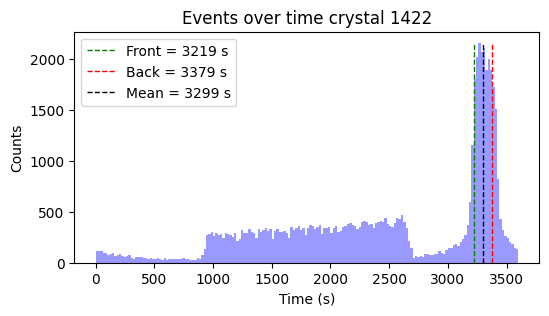

In [64]:
#id = np.random.randint(0, 3072*2)
id = 1422

binlength = 20
event_times = np.zeros(eventcounts[id], dtype = np.int16)
write_head = 0
for i in tqdm(range(0, num_rows, 1000000)):
    chunk = data[i:i+1000000]
    if id < 3072:
        chunk = chunk[chunk[:, 3] == id]
    if id >= 3072:
        chunk = chunk[chunk[:, 1] == id - 3072]
    if len(chunk) > 0:
        event_times[write_head:write_head+len(chunk)] = chunk[:, 5]
        write_head += len(chunk)
print(id)
plt.figure(1, figsize = (6, 3))
hist, bins = plt.hist(event_times, bins = int(3600 / binlength), color = 'blue', alpha = 0.4)[0:2]
bins_in_peak = np.where(hist > 0.75 * np.max(hist))[0]
front, back = bins[bins_in_peak[0]], bins[bins_in_peak[-1]]
if np.abs((front - back)) > 2000:
    print(bins_in_peak)
    print(front, back)
    front_bins = bins_in_peak[bins_in_peak < 1800/binlength]
    back_bins = bins_in_peak[bins_in_peak > 1800/binlength]
    print(front_bins, back_bins)
    if len(front_bins) > len(back_bins):
        print('Special handling, front longer')
        front, back = bins[back_bins[0]] - 3600, bins[front_bins[-1]]
    else:
        print('Special handling, back longer')
        front, back = bins[back_bins[0]], bins[front_bins[-1]] + 3600
plt.vlines(front, 0, np.max(hist), color = 'green', linestyle = '--', linewidth = 1, label = f'Front = {round(front)} s')
plt.vlines(back, 0, np.max(hist), color = 'red', linestyle = '--', linewidth = 1, label = f'Back = {round(back)} s')
plt.vlines((front+back)/2, 0, np.max(hist), color = 'black', linestyle = '--', linewidth = 1, label = f'Mean = {round((front + back) / 2)} s')
print(len(bins_in_peak) * binlength, (front + back) / 2)
#plt.grid()
plt.title('Events over time crystal ' + str(id))
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.legend()
plt.show()


In [71]:
peaks = np.zeros(3072 * 2, dtype=np.float32)
id_chunksize = 64
runtime, binlength = 900, 5
for id_chunk_start in tqdm(range(0, 3072 * 2, id_chunksize)):
    id_chunk_end = min(id_chunk_start + id_chunksize, 3072 * 2)
    n_ids = id_chunk_end - id_chunk_start
    id_range = np.arange(id_chunk_start, id_chunk_end)

    # Prepare storage for each id in chunk
    event_times_chunk = [np.zeros(eventcounts[id], dtype=np.int16) for id in id_range]
    write_heads = np.zeros(n_ids, dtype=np.int32)

    # Loop through data only once per chunk for all ids in id_range
    for i in range(0, num_rows, 1000000):
        chunk = data[i:i+1000000]
        # Left IDs
        maskL = (id_range < 3072)
        if np.any(maskL):
            idsL = id_range[maskL]
            for idx, id_val in enumerate(idsL):
                matches = np.where(chunk[:, 3] == id_val)[0]
                if len(matches) > 0:
                    et = event_times_chunk[idx]
                    wh = write_heads[idx]
                    vals = chunk[matches, 5]
                    et[wh:wh+len(vals)] = vals
                    write_heads[idx] += len(vals)
        # Right IDs
        maskR = (id_range >= 3072)
        if np.any(maskR):
            idsR = id_range[maskR]
            for idx, id_val in enumerate(idsR):
                real_idx = idx if not maskL[idx] else np.where(maskR)[0][np.where(idsR == id_val)[0][0]]
                mapped_id = id_val - 3072
                matches = np.where(chunk[:, 1] == mapped_id)[0]
                if len(matches) > 0:
                    et = event_times_chunk[real_idx]
                    wh = write_heads[real_idx]
                    vals = chunk[matches, 5]
                    et[wh:wh+len(vals)] = vals
                    write_heads[real_idx] += len(vals)
    # Now compute peaks for each id in this chunk
    for id_offset, event_times in enumerate(event_times_chunk):
        if len(event_times) == 0:
            continue
        hist, bins = np.histogram(event_times, bins=int(runtime / binlength))
        bins_in_peak = np.where(hist > 0.75 * np.max(hist))[0]
        if len(bins_in_peak) == 0:
            continue
        front, back = bins[bins_in_peak[0]], bins[bins_in_peak[-1]]
        if np.abs((front - back)) > runtime / 2:
            front_bins = bins_in_peak[bins_in_peak < runtime / 2 / binlength]
            back_bins = bins_in_peak[bins_in_peak > runtime / 2 / binlength]
            if len(front_bins) > len(back_bins):
                front, back = bins[back_bins[0]] - runtime, bins[front_bins[-1]]
            else:
                front, back = bins[back_bins[0]], bins[front_bins[-1]] + runtime
        peaks[id_chunk_start + id_offset] = (front + back) / 2


100%|██████████| 96/96 [12:51<00:00,  8.04s/it]


In [72]:
with open('peaksh.txt', 'w') as f:
    for i in range(3072 * 2):
        f.write(f'{peaks[i]}\n')

241.75653861832257
903.036221442099


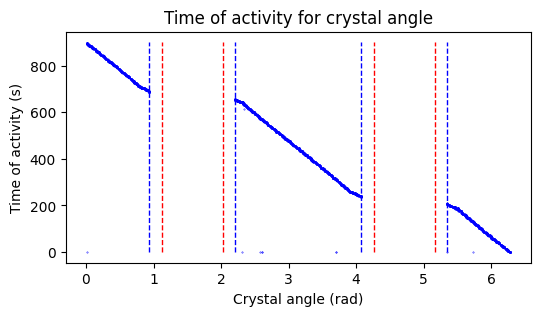

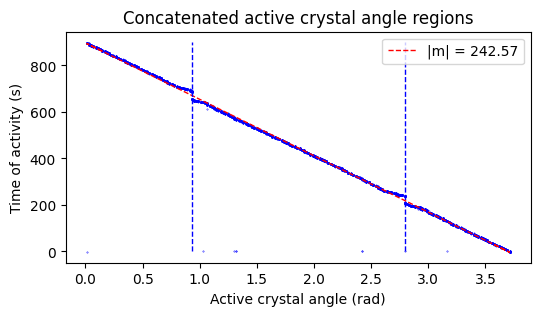

In [90]:
with open('peaksh.txt', 'r') as f:
    peaks = np.array([float(line.strip()) for line in f])
runtime = 900

mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
angles = np.zeros(3072*2, dtype = np.float32)
for i in range(3072*2):
    x, y = mapdf.iloc[i, 0], mapdf.iloc[i, 1]
    angles[i] = np.arctan2(y, x)

plt.figure(1, figsize = (6, 3))
angles[angles < 0] += 2 * np.pi
angles = angles
plt.scatter(angles, peaks, s = 0.1, color = 'blue')

boundangles = np.array([-1.12011132679, -2.02148132679, -4.26170398, -5.16307398])
boundangles = -boundangles
boundanglesblue = np.array([0.9306883746959953, 2.210904278893798, 4.072281028285788, 5.352496932483591])
plt.vlines(boundangles, 0, runtime, color = 'red', linestyle = '--', linewidth = 1)
plt.vlines(boundanglesblue, 0, runtime, color = 'blue', linestyle = '--', linewidth = 1)
plt.title('Time of activity for crystal angle')
plt.xlabel('Crystal angle (rad)')
plt.ylabel('Time of activity (s)')
plt.figure(2, figsize = (6, 3))
#xlims = [(0, boundangles[0]), (boundangles[1], boundangles[2]), (boundangles[3], 2*np.pi)]
#widths = [xmax - xmin for xmax, xmin in xlims]
#fig, ax = plt.subplots(1, 3, figsize = (6, 3), sharey = True, gridspec_kw = {'width_ratios': widths})
#angles1, peaks1 = angles[angles < xlims[0][1]], peaks[angles < xlims[0][1]]
#angles2, peaks2 = angles[(angles > xlims[1][0]) & (angles < xlims[1][1])], peaks[(angles > xlims[1][0]) & (angles < xlims[1][1])]
#angles3, peaks3 = angles[angles > xlims[2][0]], peaks[angles > xlims[2][0]]
#ax[0].scatter(angles1, peaks1, s = 0.1, color = 'blue')
#ax[1].scatter(angles2, peaks2, s = 0.1, color = 'blue')
#ax[2].scatter(angles3, peaks3, s = 0.1, color = 'blue')
#plt.subplots_adjust(hspace=0, wspace=0) # Spacing

extraangleoffset = (64.17765160986595 - 53.32451591197069) * np.pi / 180
angles1 = angles[angles < boundangles[0]]
peaks1 = peaks[angles < boundangles[0]]
angles2 = angles[(angles > boundangles[1]) & (angles < boundangles[2])] - (boundangles[1] - boundangles[0]) - 2*extraangleoffset
peaks2 = peaks[(angles > boundangles[1]) & (angles < boundangles[2])]
angles3 = angles[angles > boundangles[3]] - (boundangles[3] + boundangles[1] - boundangles[2] - boundangles[0]) - 4*extraangleoffset
peaks3 = peaks[angles > boundangles[3]]
plt.scatter(angles1, peaks1, s = 0.1, color = 'blue')
plt.scatter(angles2, peaks2, s = 0.1, color = 'blue')
plt.scatter(angles3, peaks3, s = 0.1, color = 'blue')

def linear(x, m, b):
    return m * x + b
concat_angles = np.concatenate([angles1, angles2, angles3])
concat_peaks = np.concatenate([peaks1, peaks2, peaks3])
popt, _ = curve_fit(linear, concat_angles, concat_peaks)
plt.plot(concat_angles, linear(concat_angles, *popt), color = 'red', linewidth = 1, linestyle = '--', label = f'|m| = {np.abs(popt[0]):.2f}')
plt.vlines(boundanglesblue[0], 0, runtime, color = 'blue', linestyle = '--', linewidth = 1)
plt.vlines(boundanglesblue[2]-boundanglesblue[1]+boundanglesblue[0], 0, runtime, color = 'blue', linestyle = '--', linewidth = 1)
plt.legend()
plt.title('Concatenated active crystal angle regions')
plt.xlabel('Active crystal angle (rad)')
plt.ylabel('Time of activity (s)')
# Expected slope
coveredangle = boundangles[2] - boundangles[1] + boundangles[0] - boundangles[3] + 2*np.pi - 4*extraangleoffset
expected_slope = runtime / coveredangle
print(expected_slope)
apparentruntime = -popt[0] * coveredangle
print(apparentruntime)


plt.show()



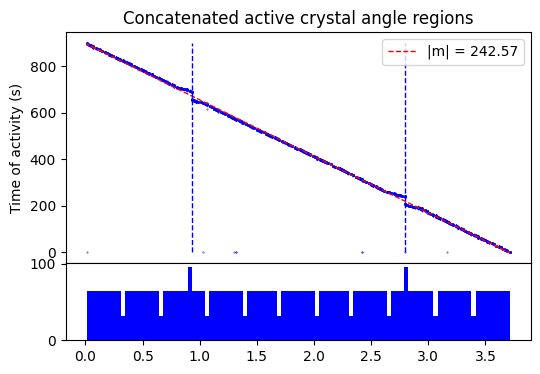

In [85]:
fig, ax = plt.subplots(2, 1, figsize = (6, 4), gridspec_kw = {'height_ratios': [3, 1]})
plt.subplots_adjust(hspace = 0)
ax[0].scatter(angles1, peaks1, s = 0.1, color = 'blue')
ax[0].scatter(angles2, peaks2, s = 0.1, color = 'blue')
ax[0].scatter(angles3, peaks3, s = 0.1, color = 'blue')
ax[0].plot(concat_angles, linear(concat_angles, *popt), color = 'red', linewidth = 1, linestyle = '--', label = f'|m| = {np.abs(popt[0]):.2f}')
ax[0].vlines(boundanglesblue[0], 0, runtime, color = 'blue', linestyle = '--', linewidth = 1)
ax[0].vlines(boundanglesblue[2]-boundanglesblue[1]+boundanglesblue[0], 0, runtime, color = 'blue', linestyle = '--', linewidth = 1)
ax[0].legend()
ax[0].set_title('Concatenated active crystal angle regions')
ax[0].set_xlabel('Active crystal angle (rad)')
ax[0].set_ylabel('Time of activity (s)')

ax[1].hist(concat_angles, bins = 100, color = 'blue')

plt.show()



In [ ]:
# Sinogram approach

